In [1]:
from typing import Optional, Dict, List
from datetime import datetime, timedelta, timezone
from collections import defaultdict

from api_henrik import AffinitiesEnum, UnofficialApi, Match
from db_valorant import ValorantDB


TIMESPAN = 200
MATCH_COUNT_MAX = 200

episode_act_formatter = lambda e, a: f'e{e}a{a}'
ACTS_OF_INTEREST = [('10', '6'), ('11', '1')]
# ACTS_OF_INTEREST = [('11', '1')]
ACTS_OF_INTEREST_STR = [episode_act_formatter(*act) for act in ACTS_OF_INTEREST]
CURRENT_EPISODE, CURRENT_ACT = ACTS_OF_INTEREST[-1]
CURRENT_ACT_STR = f'e{CURRENT_EPISODE}a{CURRENT_ACT}'
REGION = str(AffinitiesEnum.NA)

api = UnofficialApi()
db = ValorantDB(region=REGION)

# my_puuid = api.get_account_by_name("hit for 0", "sadge").puuid
# my_puuid = api.get_account_by_name("i am bot", "7911").puuid
my_puuid = api.get_account_by_name("0dmg", "sadge").puuid

db.update_match_history_for_puuid(my_puuid)
my_account = db.get_profile_by_puuid(my_puuid)
# my_puuid

In [2]:
from match_history_processor import MatchHistoryProcessor

# puuid = api.get_account_by_name("hit for 0", "sadge").puuid
# history = MatchHistoryProcessor(puuid, [('10','6'), ('11','1')], db, match_count_max=200)
# history.recent_matches[0]

In [3]:
# [g for g in history.recent_matches if any([p.tag == '8174' for p in g.players])][0].metadata.url

In [4]:
### OLD_FILTER
# from api_henrik import V1LifetimeMmrHistoryItem


# # match_history = list(filter(None, my_account.match_history.values()))
# seasonal_history: Dict[str, Dict[datetime, V1LifetimeMmrHistoryItem]] = defaultdict(dict)
# for game in my_account.match_history.values():
#     seasonal_history[game.season.short].update({game.datetime: game})

# # Considers matches in last TIMESPAN days, and from the current episode & act.
# threshold = datetime.now(timezone.utc) - timedelta(days=TIMESPAN)

# recent_history = dict(
#     sorted(
#         ((datecode, game) for datecode, game in list(seasonal_history[CURRENT_ACT_STR].items()) if datecode >= threshold and game.elo != 0),
#         key=lambda x: x[0],
#         reverse=True
#     )[:MATCH_COUNT_MAX]
# )

# recent_matches: List[Match] = [db.get_match(match.match_id) for match in recent_history.values()]
# recent_mmr: Dict[str, V1LifetimeMmrHistoryItem] = {
#     game.match_id: game for game in recent_history.values()
# }

# del seasonal_history
# del recent_history

In [5]:
from api_henrik import V1LifetimeMmrHistoryItem


# match_history = list(filter(None, my_account.match_history.values()))
seasonal_history: Dict[str, Dict[datetime, V1LifetimeMmrHistoryItem]] = defaultdict(dict)
for game in my_account.match_history.values():
    seasonal_history[game.season.short].update({game.datetime: game})

# Considers matches in last TIMESPAN days, and from the current episode & act.
threshold = datetime.now(timezone.utc) - timedelta(days=TIMESPAN)


matches_selection = [ 
  (datecode, game)
  for (act) in ACTS_OF_INTEREST_STR
  for (datecode, game) in seasonal_history[act].items()
]

recent_history = dict(
    sorted(
        ((datecode, game) for datecode, game in matches_selection if datecode >= threshold),
        key=lambda x: x[0],
        reverse=True
    )[:MATCH_COUNT_MAX]
)

recent_matches: List[Match] = [db.get_match(match.match_id) for match in recent_history.values()]
recent_matches_by_id: Dict[str, Match] = {g.metadata.match_id: g for g in recent_matches}
recent_mmr: Dict[str, V1LifetimeMmrHistoryItem] = {
    game.match_id: game for game in recent_history.values()
}
recent_season_labels: Dict[str, str] = {g.metadata.match_id: recent_mmr[g.metadata.match_id].season.short for g in recent_matches}
recent_previous_match: Dict[str, Optional[str]] = {
    recent_matches[i].metadata.match_id: recent_matches[i+1].metadata.match_id if i < len(recent_matches) - 1 else None
    for i in range(len(recent_matches))
}
recent_is_placement: Dict[str, bool] = {g.metadata.match_id: recent_mmr[g.metadata.match_id].tier.name == 'Unrated' for g in recent_matches}
recent_is_newly_placed: Dict[str, bool] = {}
for match_id in recent_is_placement:
    previous_match_id = recent_previous_match[match_id]
    is_newly_placed_rank = False if previous_match_id is None else recent_is_placement[previous_match_id] and not recent_is_placement[match_id]
    recent_is_newly_placed[match_id] = is_newly_placed_rank

# del seasonal_history
del recent_history

In [6]:
# list(seasonal_history['e10a6'].items())[::-1]

In [7]:
# len(seasonal_history['e11a1']) - 5

In [8]:
def get_last_known_elo(match_id: str) -> Optional[int]:
    '''Given a match id, get the last non-zero elo value if one is available'''
    last_elo = recent_mmr[match_id].elo
    if last_elo != 0:
        return last_elo
    
    match_id = recent_previous_match[match_id]
    if match_id is None:
        return None
    
    return get_last_known_elo(match_id)

match_id = recent_matches[0].metadata.match_id
get_last_known_elo(match_id)

1031

In [9]:
import numpy as np
import math


VALORANT_RANKS = ["Iron 1", "Iron 2", "Iron 3", "Bronze 1", "Bronze 2", "Bronze 3", "Silver 1", "Silver 2", "Silver 3",
                  "Gold 1", "Gold 2", "Gold 3", "Platinum 1", "Platinum 2", "Platinum 3", "Diamond 1", "Diamond 2", "Diamond 3",
                  "Ascendant 1", "Ascendant 2", "Ascendant 3", "Immortal 1", "Immortal 2", "Immortal 3", "Radiant"]
TIER_THRESHOLDS = [
    (idx*100, name) for idx, name in enumerate(VALORANT_RANKS)
]

def lookup_rank(index: int) -> str:
    index = max(0, min(24, index))
    return VALORANT_RANKS[index]

def index_rank(rank_str: str) -> int:
    return VALORANT_RANKS.index(rank_str)

def map_rank_value(rank_value: Optional[float], include_rr=True) -> Optional[str]:
    """
    Converts an rank float into:
      '<Rank Name> <RR> RR'

    Example:
      12.34 -> 'Gold 1 34 RR'
    """
    if rank_value < 0:
        raise ValueError("rank_value must be positive")
    
    if rank_value is None:
        return None

    tier_index = int(math.floor(rank_value))
    rr = int((rank_value - tier_index) * 100)

    # Clamp safety (in case of floating point weirdness)
    rr = max(0, min(rr, 99))

    rank_name = lookup_rank(tier_index)
    
    if include_rr:
        return f"{rank_name} {rr} RR"
    else:
        return rank_name

map_rank_value(9.234)

'Gold 1 23 RR'

In [10]:
from typing import Tuple


def valorant_act_in_range(range_start_act: Tuple[str, str], n: int) -> List[Tuple[str, str]]:
    """
    Returns a list of (episode, act) tuples going backwards from range_start_act,
    inclusive, with total length n.

    range_start_act: tuple(str, str) e.g. ('10', '6') for E10A6
    n: int, number of acts to include
    """
    episode = int(range_start_act[0])
    act = int(range_start_act[1])
    result = []

    # Helper function to get max acts for an episode
    def max_acts(ep):
        return 6 if ep >= 10 else 3

    while len(result) < n and episode > 0:
        result.append((str(episode), str(act)))
        
        act -= 1
        if act == 0:
            episode -= 1
            if episode > 0:
                act = max_acts(episode)

    return result

valorant_act_in_range(('12', '1'), 5)

[('12', '1'), ('11', '6'), ('11', '5'), ('11', '4'), ('11', '3')]

In [11]:
def get_last_known_elo_from_puuid(puuid: str, db: ValorantDB, match_id: str = None, history: MatchHistoryProcessor = None) -> Optional[int]:
    '''Given a match id, get the last non-zero elo value if one is available'''
    if history is None:
        recent_acts = valorant_act_in_range(ACTS_OF_INTEREST[-1], 3)[1:]
        history = MatchHistoryProcessor(puuid, recent_acts, db, match_count_max=5, timespan=120)
    if match_id is None:
        match_id = history.recent_matches[0].metadata.match_id
    
    last_elo = history.recent_mmr[match_id].elo
    if last_elo != 0:
        return last_elo
    
    match_id = history.recent_previous_match[match_id]
    if match_id is None:
        return None
    
    return get_last_known_elo_from_puuid(puuid, db, match_id, history)

puuid = '1db7daa9-3020-547c-94b0-e8b1d4392453'
get_last_known_elo_from_puuid(puuid, db)

801

In [12]:
def calculate_average_ranks_basic(
    match: Match,
    exclude_puuid: str
) -> Dict[str, Optional[float]]:
    """
    Calculates average ranks for:
      - allies
      - opponents
      - entire lobby
    Excludes the player with `exclude_puuid`
    """

    # Find excluded player to determine their team
    excluded_player = next(
        (p for p in match.players if p.puuid == exclude_puuid),
        None
    )

    if not excluded_player:
        raise ValueError(f"Player with puuid {exclude_puuid} not found in match")

    ally_team = excluded_player.team_id

    ally_ranks = []
    opponent_ranks = []
    lobby_ranks = []

    for player in match.players:
        # Skip excluded player
        if player.puuid == exclude_puuid:
            continue

        # Skip invalid rank values
        if player.currenttier is None:
            continue
        if player.currenttier < 3:
            continue
        
        player_rank = None
        
        # Find last known rank for unrated plaeyrs
        if player.currenttier_patched != "Unrated":   
            player_rank = player.currenttier - 3 # API indexes against list ["Unrated", "Unknown", "Unranked", "Iron 1"...]
        
        # Brand new player, no rank data. Skip.
        if player_rank is None:
            continue
        
        lobby_ranks.append(player_rank)

        if player.team_id == ally_team:
            ally_ranks.append(player_rank)
        else:
            opponent_ranks.append(player_rank)

    return {
        "allies_avg_rank": np.average(ally_ranks),
        "opponents_avg_rank": np.average(opponent_ranks),
        "lobby_avg_rank": np.average(lobby_ranks),
    }

# calculate_average_ranks_basic(recent_matches[0], my_account.puuid)

In [13]:
from typing import List, Dict, Optional

def gather_rank_average_lists(match_history: List["Match"], excluded_puuid: str) -> Dict[str, Optional[List[float]]]:
    """
    Collects average rank values for allies, opponents, and the entire lobby 
    across a list of matches, excluding a specific player.

    For each match, this function calculates the average rank for allies, opponents,
    and the full lobby, ignoring the player identified by `excluded_puuid`. 
    The results are returned as lists per category for all matches.

    Parameters:
        match_history (List[Match]): A list of Match objects representing the match history.
        excluded_puuid (str): The unique identifier of the player to exclude from calculations.

    Returns:
        Dict[str, Optional[List[float]]]: A dictionary with keys like 'allies', 'opponents', 
        'lobby', each mapping to a list of average ranks per match, or None if no values exist.
    """
    results = [calculate_average_ranks_basic(each, excluded_puuid) for each in match_history]

    fields = results[0].keys()
    output = {}

    for field in fields:
        values = [r[field] for r in results if r[field] is not None]
        output[field] = values if values else None

    return output

rank_averages = gather_rank_average_lists(recent_matches, my_account.puuid)

In [14]:
import numpy as np
from scipy.interpolate import UnivariateSpline
from typing import List, Optional, Dict

def lerp(a: float, b: float, t: float) -> float:
    """Linear interpolation from a to b by factor t."""
    return a + (b - a) * t

def ilerp(a: float, b: float, v: float) -> float:
    """Inverse linear interpolation: returns where v falls between a and b."""
    return (v - a) / (b - a) if b != a else 0.0

def remap(v: float, in_min: float, in_max: float, out_min: float, out_max: float) -> float:
    """Remap value v from input range to output range."""
    t = ilerp(in_min, in_max, v)
    return lerp(out_min, out_max, t)

def clamp(v: float, min_val: float, max_val: float) -> float:
    """Clamp value v to range [min_val, max_val]."""
    return max(min_val, min(max_val, v))

def predict_mmr(rank_averages_lists: Dict[str, List[Optional[float]]], match_index: int) -> Optional[float]:
    """
    Predict MMR (or average rank) at a given match index using a smoothing spline on lobby_avg_rank.
    
    Parameters:
    - rank_averages_lists: dictionary containing 'lobby_avg_rank' list (with possible None values)
    - match_index: the match index to predict (1-based)
    
    Returns:
    - predicted MMR/rank as float, or None if prediction is not possible
    """
    lobby_values = np.array(rank_averages_lists.get("lobby_avg_rank", []), dtype=float)
    max_rank = np.max(lobby_values)
    min_rank = np.min(lobby_values)
    mask = ~np.isnan(lobby_values)
    n = len(lobby_values)
    
    
    if mask.sum() < 4:
        # Not enough data to fit a spline
        return None

    x_clean = np.arange(1, len(lobby_values) + 1)[mask]
    y_clean = lobby_values[mask]

    # Smoothing factor
    s = len(y_clean) * np.var(y_clean) * 0.75
    try:
        k = clamp(remap(n, 0, 20, 1, 3), 1, 3)
        spline = UnivariateSpline(x_clean, y_clean, s=s, k=k)
        return max(min(float(spline(match_index)), max_rank), min_rank)
        # return float(spline(match_index))
    except:
        return None

predicted_matches_mmr: Dict[str, float] = {
    recent_matches[idx].metadata.match_id: predict_mmr(rank_averages, idx)
    for idx in range(len(recent_matches))
}

# map_rank_value(predicted_matches_mmr['0148150f-5c8d-438f-a7f2-2659241d61d7'])

In [15]:
def get_last_known_elo_from_puuid_spline(puuid: str, db: ValorantDB) -> Optional[int]:
    '''Given a match id, get the last non-zero elo value if one is available'''
    recent_acts = valorant_act_in_range(ACTS_OF_INTEREST[-1], 3)[1:]
    history = MatchHistoryProcessor(puuid, recent_acts, db, match_count_max=5, timespan=120)
        
    recent_matches: List[Match] = history.recent_matches
    if len(recent_matches) == 0:
        return None
    
    lobby_averages = gather_rank_average_lists(recent_matches, puuid)
    
    spline_value = predict_mmr(lobby_averages, 0) # Spline value
    average_value = np.average(lobby_averages['lobby_avg_rank']) # Average
    if spline_value is None:
        spline_value = average_value
    return np.average([spline_value, average_value])

puuid_ = '1db7daa9-3020-547c-94b0-e8b1d4392453'
get_last_known_elo_from_puuid_spline(puuid_, db)

9.572222222222223

In [16]:
def calculate_average_ranks_spline(
    match: Match,
    exclude_puuid: str,
    keep_lists: bool = False
) -> Dict[str, Optional[float]]:
    """
    Calculates average ranks for:
      - allies
      - opponents
      - entire lobby
    Excludes the player with `exclude_puuid`
    """

    # Find excluded player to determine their team
    excluded_player = next(
        (p for p in match.players if p.puuid == exclude_puuid),
        None
    )

    if not excluded_player:
        raise ValueError(f"Player with puuid {exclude_puuid} not found in match")

    ally_team = excluded_player.team_id

    ally_ranks = []
    opponent_ranks = []
    lobby_ranks = []
    
    unrated_count = [p.currenttier_patched for p in match.players].count("Unrated")
    should_lookup_unrated = unrated_count / 9 > 0.4

    for player in match.players:
        # Skip excluded player
        if player.puuid == exclude_puuid:
            continue
        
        player_rank = None
        
        # Find last known rank for unrated plaeyrs
        if player.currenttier_patched == "Unrated" and should_lookup_unrated:
            # last_known_elo = get_last_known_elo_from_puuid(player.puuid, db)
            last_known_elo = get_last_known_elo_from_puuid_spline(player.puuid, db)
            if last_known_elo is not None:
                player_rank = last_known_elo
        elif player.currenttier_patched != "Unrated":    
            player_rank = player.currenttier - 3 # API indexes against list ["Unrated", "Unknown", "Unranked", "Iron 1"...]
        
        # Brand new player, no rank data. Skip.
        if player_rank is None:
            continue
        
        lobby_ranks.append(player_rank)

        if player.team_id == ally_team:
            ally_ranks.append(player_rank)
        else:
            opponent_ranks.append(player_rank)

    if not keep_lists:
        return {
            "allies_avg_rank": np.average(ally_ranks),
            "opponents_avg_rank": np.average(opponent_ranks),
            "lobby_avg_rank": np.average(lobby_ranks),
            "lobby_std": np.std(lobby_ranks),
        }
    else:
        return {
            "allies_avg_rank": (np.average(ally_ranks), ally_ranks),
            "opponents_avg_rank": (np.average(opponent_ranks), opponent_ranks),
            "lobby_avg_rank": (np.average(lobby_ranks), lobby_ranks),
            "lobby_std": (np.std(lobby_ranks), lobby_ranks),
        }
        

calculate_average_ranks_spline(recent_matches[0], my_account.puuid)

{'allies_avg_rank': 7.0,
 'opponents_avg_rank': 6.6,
 'lobby_avg_rank': 6.777777777777778,
 'lobby_std': 1.227262335243029}

In [17]:
from typing import List, Dict, Optional

def gather_rank_average_lists_spline(match_history: List["Match"], excluded_puuid: str) -> Dict[str, Optional[List[float]]]:
    """
    Collects average rank values for allies, opponents, and the entire lobby 
    across a list of matches, excluding a specific player.

    For each match, this function calculates the average rank for allies, opponents,
    and the full lobby, ignoring the player identified by `excluded_puuid`. 
    The results are returned as lists per category for all matches.

    Parameters:
        match_history (List[Match]): A list of Match objects representing the match history.
        excluded_puuid (str): The unique identifier of the player to exclude from calculations.

    Returns:
        Dict[str, Optional[List[float]]]: A dictionary with keys like 'allies', 'opponents', 
        'lobby', each mapping to a list of average ranks per match, or None if no values exist.
    """
    results = [calculate_average_ranks_spline(each, excluded_puuid) for each in match_history]

    fields = results[0].keys()
    output = {}

    for field in fields:
        values = [r[field] for r in results if r[field] is not None]
        output[field] = values if values else None

    return output


rank_averages = gather_rank_average_lists_spline(recent_matches, my_account.puuid)

In [18]:
def calculate_placement_regions(reverse: bool = False, offset: int = 0, matches_selection: Optional[List[Match]] = None):
    """
    Calculate contiguous placement regions.

    Args:
        reverse (bool): If True, treats the list as reversed.
        offset (int): Number of matches removed at the start; shifts indices.

    Returns:
        List of (start, end) tuples in original coordinates (adjusted for reverse and offset).
    """
    if matches_selection is not None:
        placements = [recent_is_placement[game.metadata.match_id] for game in matches_selection]
        newly_placed = [recent_is_newly_placed[game.metadata.match_id] for game in matches_selection]
    else:
        placements = list(recent_is_placement.values())  # list[bool]
        newly_placed = list(recent_is_newly_placed.values())  # list[bool]
    

    placements = [a or b for (a,b) in zip(placements, newly_placed)]

    placement_ranges = []
    in_block = False
    start = None

    for i, is_placement in enumerate(placements):
        if is_placement and not in_block:
            in_block = True
            start = i
        elif not is_placement and in_block:
            placement_ranges.append((start, i - 1))
            in_block = False

    if in_block:
        placement_ranges.append((start, len(placements) - 1))

    # map back to original coordinates if reversed
    if reverse:
        n = len(placements)
        placement_ranges = [(n - 1 - end, n - 1 - start) for start, end in placement_ranges]

    # apply offset
    placement_ranges = [(max(0, start + offset), end + offset) for start, end in placement_ranges]

    return placement_ranges

# Example usage
print(calculate_placement_regions(False, offset=0))
print(calculate_placement_regions(True, offset=-1))

[(154, 158), (185, 189)]
[(30, 34), (0, 3)]


In [19]:
# n = len(list(recent_is_placement.keys())) - 2
# match_id = list(recent_is_placement.keys())[n - 4]
# recent_mmr[match_id].as_dict()

Predicted MMR at match 0: Bronze 3 55 RR


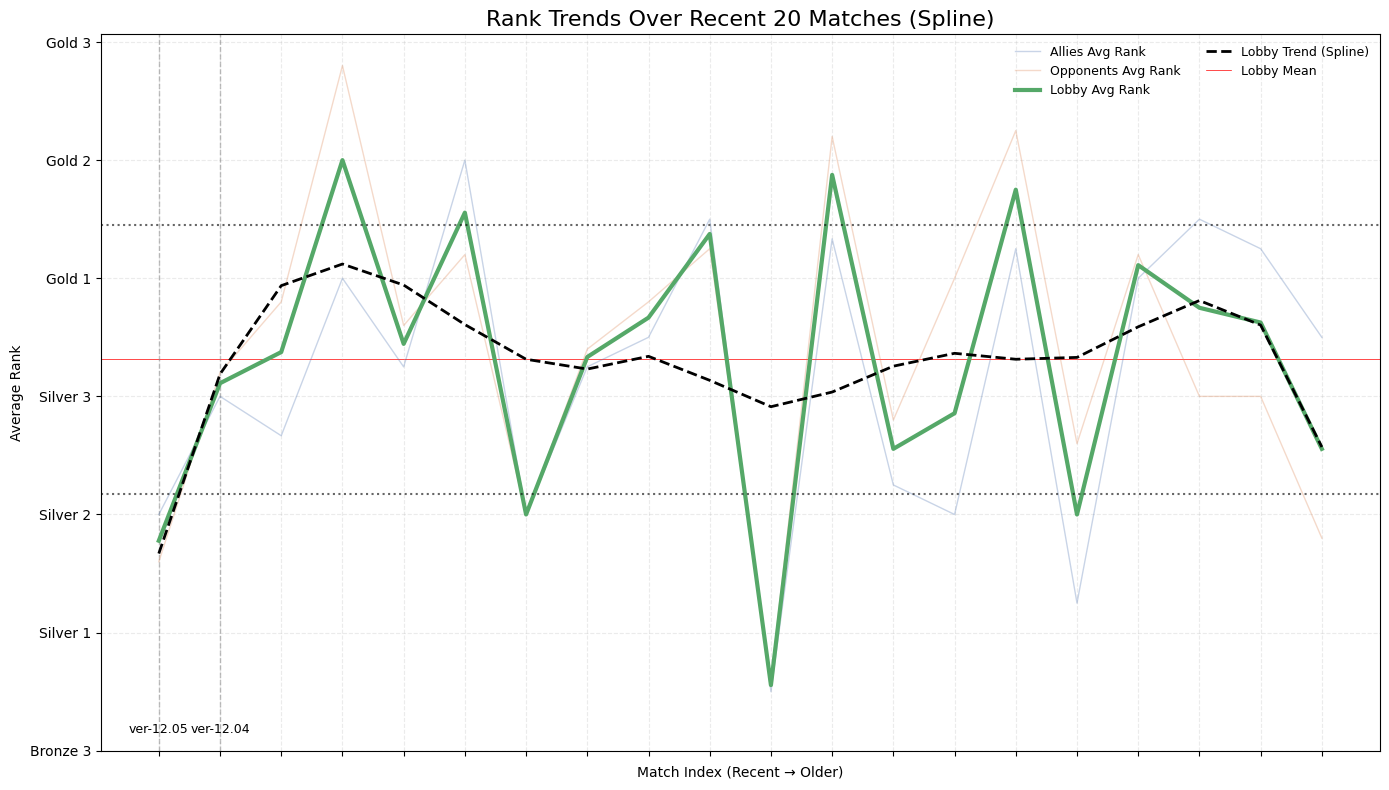

In [ ]:
# --- Modified plot function using the same spline logic ---
import random
from matplotlib import pyplot as plt

def find_change_indices(lst):
    if not lst:
        return []
    
    result = [(0, lst[0])]  # Start with the first element
    
    for i in range(1, len(lst)):
        if lst[i] != lst[i-1]:
            result.append((i, lst[i]))
    
    return result

def plot_rank_trends(rank_averages: Dict[str, List[Optional[float]]], recent_matches: List[Match], N: Optional[int] = None):
    total_matches = len(next(iter(rank_averages.values())))
    game_versions = [recent_matches[i].metadata.game_version for i in range(total_matches)]
    game_versions = [ver[:ver.index('-shipping')].replace('release-','ver-') for ver in game_versions]
    version_changes = find_change_indices(game_versions)
    
    end_idx = N if N else total_matches
    matches = np.arange(1, end_idx + 1)

    plt.figure(figsize=(14, 8))

    colors = {
        "allies_avg_rank": "#4C72B0",
        "opponents_avg_rank": "#DD8452",
        "lobby_avg_rank": "#55A868",
    }

    emphasis = {
        "allies_avg_rank": 0.3,
        "opponents_avg_rank": 0.3,
        "lobby_avg_rank": 1.0,
    }
    
    y_min, y_max = plt.ylim()
    # Add vertical lines at version changes
    for idx, version in version_changes:
        if idx < end_idx:
            plt.axvline(x=idx + 1, color='gray', linestyle='--', alpha=0.5, linewidth=1)
            
            # Add text label for each version slightly above the bottom
            plt.text(idx + 1, 0.02, version, 
                    rotation=0, verticalalignment='bottom', 
                    horizontalalignment='center', fontsize=9,
                    transform=plt.gca().get_xaxis_transform())
    
    # # Set x-axis ticks at version changes with version labels
    # version_positions = [idx + 1 for idx, _ in version_changes if idx < end_idx]
    # version_labels = [version for idx, version in version_changes if idx < end_idx]
    # plt.xticks(version_positions, version_labels, rotation=0, ha='center')    
    plt.xticks([], [], rotation=0, ha='center')    

    for field, values in rank_averages.items():
        if field == "lobby_std":
            continue

        y = np.array([v if v is not None else np.nan for v in values[:end_idx]])
        plt.plot(
            matches,
            y,
            color=colors.get(field, "gray"),
            linewidth=3 if field == "lobby_avg_rank" else 1,
            alpha=emphasis.get(field, 0.5),
            label=field.replace("_", " ").title()
        )

        # if field == "lobby_avg_rank":
        #     mask = ~np.isnan(y)
        #     if mask.sum() >= 4:
        #         x_clean = matches[mask]
        #         y_clean = y[mask]
        #         s = len(y_clean) * np.var(y_clean) * 0.69
        #         spline = UnivariateSpline(x_clean, y_clean, s=s, k=3)
        #         trend_y = spline(matches)
        #         plt.plot(matches, trend_y, linestyle="--", color="black",
        #                  linewidth=2, label="Lobby Trend (Spline)")
        if field == "lobby_avg_rank":
            mask = ~np.isnan(y)
            if mask.sum() >= 4:
                # Build trend using predict_mmr for each match
                trend_y = [predict_mmr(rank_averages, idx) for idx in matches]
                trend_y = np.array([v if v is not None else np.nan for v in trend_y])
                plt.plot(matches, trend_y, linestyle="--", color="black",
                        linewidth=2, label="Lobby Trend (Spline)")
        

    # Lobby mean & std
    lobby = np.array(rank_averages["lobby_avg_rank"][:end_idx], dtype=float)
    lobby = lobby[~np.isnan(lobby)]

    if len(lobby):
        mean = lobby.mean()
        std = lobby.std()
        plt.axhline(mean, color="red", zorder=0, linewidth=0.5, alpha=1, label="Lobby Mean")
        plt.axhline(mean + std, color="black", linestyle=":", alpha=0.6)
        plt.axhline(mean - std, color="black", linestyle=":", alpha=0.6)
    
    ax = plt.gca()    
    placement_ranges = calculate_placement_regions(reverse=False, offset=1, matches_selection=recent_matches)
    first = True
    for start, end in placement_ranges:
        ax.axvline(start, linestyle="--", linewidth=1)
        ax.axvline(end, linestyle="--", linewidth=1)
        ax.axvspan(start - 0.5, end + 0.5, alpha=0.15,
                   label="Placement Matches" if first else None)
        first = False        

    # Axes cleanup
    step = max(1, end_idx // 15)
    plt.xticks(matches[::step])

    # all_values = [v for vals in rank_averages.values() for v in vals[:end_idx] if v is not None]
    all_values = [
        v
        for key, vals in rank_averages.items()
        if key != "lobby_std"          # ignore this key
        for v in vals[:end_idx]
        if v is not None
    ]
    if all_values:
        y_min = int(np.floor(min(all_values)))
        y_max = int(np.ceil(max(all_values))) + 1
        y_ticks = np.arange(y_min, y_max, 1)
        plt.yticks(y_ticks, [lookup_rank(int(t)) for t in y_ticks])

    plt.title(f"Rank Trends Over Recent {end_idx} Matches (Spline)", fontsize=16)
    plt.xlabel("Match Index (Recent → Older)")
    plt.ylabel("Average Rank")
    plt.grid(True, linestyle="--", alpha=0.25)
    plt.legend(frameon=False, ncol=2, fontsize=9)
    plt.tight_layout()
    plt.show()

selection = recent_matches[:]
rank_averages = gather_rank_average_lists_spline(selection, my_account.puuid)
idx = 0
predicted_mmr = map_rank_value(predict_mmr(rank_averages, match_index=idx))
print(f"Predicted MMR at match {idx}:", predicted_mmr)

plot_rank_trends(rank_averages, selection)
rank_averages = gather_rank_average_lists_spline(recent_matches, my_account.puuid)

In [21]:
print(selection[0].metadata.map)
selection[0].metadata.url

Bind


'https://vtl.lol/match/ddcd7a54-1c56-41bf-a88a-8dd304a83d90'

In [22]:
# recent_matches[0].metadata.url
avrank, ranks = calculate_average_ranks_spline(recent_matches[0], my_account.puuid, keep_lists=True)['lobby_avg_rank']
print("Lobby Average: ", map_rank_value(avrank))
for v in ranks:
    print(map_rank_value(v))

Lobby Average:  Silver 1 77 RR
Silver 1 0 RR
Silver 1 0 RR
Silver 1 0 RR
Gold 1 0 RR
Silver 3 0 RR
Bronze 3 0 RR
Silver 3 0 RR
Silver 2 0 RR
Silver 1 0 RR


In [23]:
def calculate_winrate(matches, player_puuid):
    """
    Calculate winrate for a player across a list of matches,
    excluding draw matches.

    Args:
        matches (list): List of match objects
        player_puuid (str): Player's PUUID

    Returns:
        dict: {
            'wins': int,
            'losses': int,
            'games': int,
            'winrate': float
        }
    """
    wins = 0
    losses = 0

    for game in matches:
        try:
            blue_won = game.teams.blue.has_won
            red_won = game.teams.red.has_won

            # Drop draws (no winning team)
            if not blue_won and not red_won:
                continue

            # Find the player in this match
            player = next(
                p for p in game.players
                if p.puuid == player_puuid
            )

            # Determine if player's team won
            if player.team_id == "Blue":
                won = blue_won
            elif player.team_id == "Red":
                won = red_won
            else:
                continue

            if won:
                wins += 1
            else:
                losses += 1

        except (StopIteration, AttributeError):
            # Player not found or malformed match object
            continue

    games = wins + losses
    winrate = wins / games if games > 0 else 0.0

    return {
        "wins": wins,
        "losses": losses,
        "games": games,
        "winrate": winrate,
    }


calculate_winrate(recent_matches[:31], my_account.puuid)

{'wins': 19, 'losses': 11, 'games': 30, 'winrate': 0.6333333333333333}

In [24]:
from typing import Dict, List, Any

def analyze_match_history(data: Dict[str, List[float]]) -> Dict[str, Any]:
    """
    Analyze a match history dictionary containing:
        - 'allies_avg_rank'
        - 'opponents_avg_rank'
        - 'lobby_avg_rank'
        - 'lobby_std'
    
    Returns a bundle of metrics:
        - min/max per field
        - ally vs opponent delta min/max
        - most/least balanced matches (tightest/widest lobby)
    """
    result: Dict[str, Any] = {}

    # ---- min / max per field ----
    for key, values in data.items():
        min_idx = min(range(len(values)), key=values.__getitem__)
        max_idx = max(range(len(values)), key=values.__getitem__)

        result[key] = {
            "min": (values[min_idx], min_idx),
            "max": (values[max_idx], max_idx),
        }

    # ---- allies vs opponents delta (signed) ----
    allies = data["allies_avg_rank"]
    opponents = data["opponents_avg_rank"]
    deltas = [opponents[i] - allies[i] for i in range(len(allies))]

    min_delta_idx = min(range(len(deltas)), key=deltas.__getitem__)
    max_delta_idx = max(range(len(deltas)), key=deltas.__getitem__)

    result["ally_opponent_delta"] = {
        "min": (deltas[min_delta_idx], min_delta_idx),
        "max": (deltas[max_delta_idx], max_delta_idx),
        "details": {
            "min": {
                "allies_avg_rank": allies[min_delta_idx],
                "opponents_avg_rank": opponents[min_delta_idx],
            },
            "max": {
                "allies_avg_rank": allies[max_delta_idx],
                "opponents_avg_rank": opponents[max_delta_idx],
            },
        },
    }

    # ---- most and least balanced (tightest/widest lobby) ----
    lobby_std = data["lobby_std"]
    most_balanced_idx = min(range(len(lobby_std)), key=lobby_std.__getitem__)
    least_balanced_idx = max(range(len(lobby_std)), key=lobby_std.__getitem__)

    result["lobby_balance"] = {
        "most_balanced": (lobby_std[most_balanced_idx], most_balanced_idx),
        "least_balanced": (lobby_std[least_balanced_idx], least_balanced_idx),
        "details": {
            "most_balanced": {
                "lobby_std": lobby_std[most_balanced_idx],
                "allies_avg_rank": allies[most_balanced_idx],
                "opponents_avg_rank": opponents[most_balanced_idx],
            },
            "least_balanced": {
                "lobby_std": lobby_std[least_balanced_idx],
                "allies_avg_rank": allies[least_balanced_idx],
                "opponents_avg_rank": opponents[least_balanced_idx],
            },
        },
    }

    return result


results = analyze_match_history(rank_averages)
least_balanced = recent_matches[results['lobby_balance']['least_balanced'][1]]
most_balanced = recent_matches[results['lobby_balance']['most_balanced'][1]]

print(f"Most Balanced: {most_balanced.metadata.url}")
print("Most Balance:", calculate_average_ranks_spline(most_balanced, my_account.puuid, True)['lobby_std'])
print()
print(f"Least Balanced: {least_balanced.metadata.url}")
print("Least Balance:", calculate_average_ranks_spline(least_balanced, my_account.puuid, True)['lobby_std'])


Most Balanced: https://vtl.lol/match/250c8d99-d835-426e-92ad-97ce1189356f
Most Balance: (0.4517539514526256, [6, 7, 6, 6, 7, 6, 6])

Least Balanced: https://vtl.lol/match/99de4427-fa8b-4cba-aff1-21af44db5220
Least Balance: (2.449489742783178, [7, 8, 6, 12, 10, 4, 9])


In [25]:
from typing import List, Tuple

def sort_matches_by_lobby_std(recent_matches: List[Any], lobby_std: List[float]) -> List[Tuple[float, Any]]:
    """
    Sort matches by lobby_std, smallest to largest.

    Args:
        recent_matches: List of Match objects (or dicts, whatever represents a match)
        lobby_std: List of std values for each match, same order as recent_matches

    Returns:
        List of tuples: (lobby_std, match), sorted by lobby_std ascending
    """
    # Pair each match with its std
    paired: List[Tuple[float, Any]] = list(zip(lobby_std, recent_matches))

    # Sort by std
    paired.sort(key=lambda x: x[0])

    return paired


matches_by_balance = sort_matches_by_lobby_std(recent_matches, rank_averages['lobby_std'])
for score, game in matches_by_balance[-5:]:
    print(game.metadata.url)

https://vtl.lol/match/9e65be99-99c6-408f-ba26-1be11eab01ba
https://vtl.lol/match/e726cc25-388b-4824-9920-0bbdef098e88
https://vtl.lol/match/6eb7ec52-4252-471e-856a-7cf671606c70
https://vtl.lol/match/29b47a96-402d-4d5e-9cb0-9809a8978c64
https://vtl.lol/match/99de4427-fa8b-4cba-aff1-21af44db5220


Total percent: 100.0


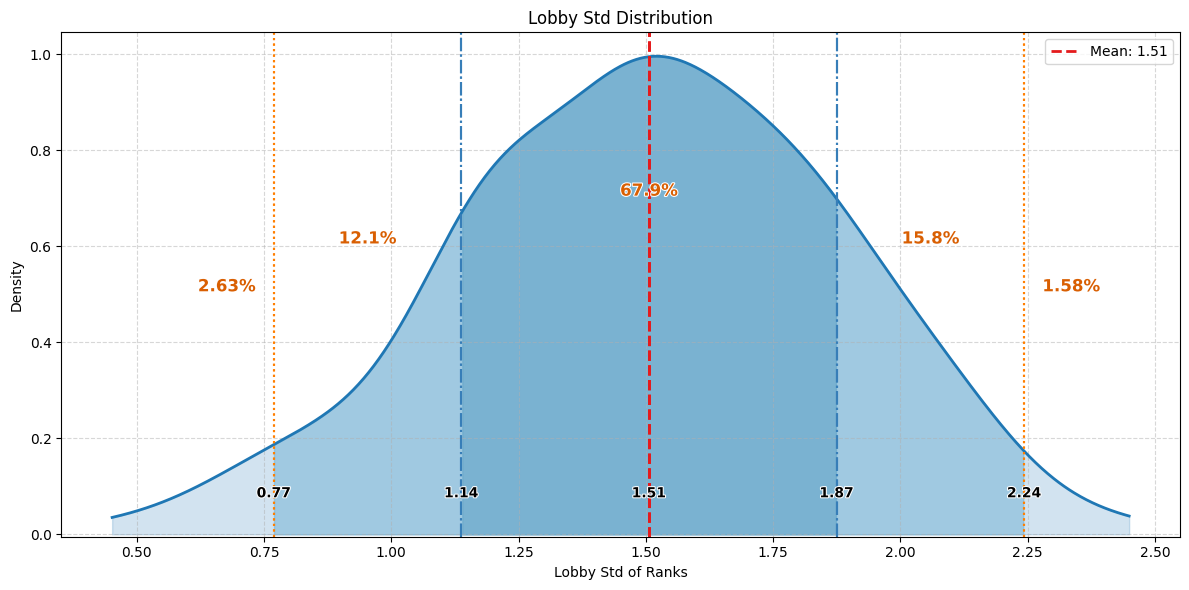

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import gaussian_kde

lobby_std = np.array(rank_averages['lobby_std'])

# Metrics
mean_std = np.mean(lobby_std)
std_std = np.std(lobby_std)

# Refined color dictionary for a more appealing bell curve
colors = {
    'kde_curve': '#1f77b4',       # Deep blue for main curve
    'shade_1sigma': "#6aa9cb",    # Soft sky blue for 1σ area
    'shade_2sigma': "#6fb0d3",    # Light peach for 2σ area
    'shade_beyond': "#6fb0d3",    # Coral for beyond 2σ
    'mean_line': '#e41a1c',       # Bold red for mean
    'line_1sigma': '#377eb8',     # Stronger blue for 1σ line
    'line_2sigma': '#ff7f00',     # Bright orange for 2σ line
    'text_1sigma': "#d95f02",     # Teal for 1σ annotation
    'text_2sigma': '#d95f02',     # Rusty orange for 2σ annotation
    'text_beyond': '#d95f02'      # Magenta for extreme area text
}

from scipy.stats import gaussian_kde

# KDE but constrained to the actual data range
kde = gaussian_kde(lobby_std)
x = np.linspace(lobby_std.min(), lobby_std.max(), 1000)
y = kde(x)

# Clip density to zero outside min/max observed values
y[x < lobby_std.min()] = 0
y[x > lobby_std.max()] = 0

plt.figure(figsize=(12,6))
plt.plot(x, y, color=colors['kde_curve'], lw=2)
plt.fill_between(x, 0, y, color=colors['kde_curve'], alpha=0.2)

# Shade ±2σ and ±1σ
plt.fill_between(x, 0, y,
                 where=(x >= mean_std - 2*std_std) & (x <= mean_std + 2*std_std),
                 color=colors['shade_2sigma'], alpha=0.5)
plt.fill_between(x, 0, y,
                 where=(x >= mean_std - std_std) & (x <= mean_std + std_std),
                 color=colors['shade_1sigma'], alpha=0.7)



# Calculate percentages
total = len(lobby_std)
# Percentages for each region
pct_inside_1sigma = np.sum((lobby_std >= mean_std - std_std) & (lobby_std <= mean_std + std_std)) / total * 100

pct_left_1to2sigma = np.sum((lobby_std >= mean_std - 2*std_std) & (lobby_std < mean_std - std_std)) / total * 100
pct_right_1to2sigma = np.sum((lobby_std > mean_std + std_std) & (lobby_std <= mean_std + 2*std_std)) / total * 100

pct_beyond_2sigma_left = np.sum(lobby_std < mean_std - 2*std_std) / total * 100
pct_beyond_2sigma_right = np.sum(lobby_std > mean_std + 2*std_std) / total * 100

# Check sum
total_pct = pct_inside_1sigma + pct_left_1to2sigma + pct_right_1to2sigma + pct_beyond_2sigma_left + pct_beyond_2sigma_right
print("Total percent:", total_pct)  # should be very close to 100

# Draw vertical lines
plt.axvline(mean_std, color=colors['mean_line'], linestyle='--', lw=2, label=f"Mean: {mean_std:.2f}")
plt.axvline(mean_std - std_std, color=colors['line_1sigma'], linestyle='-.', lw=1.5)
plt.axvline(mean_std + std_std, color=colors['line_1sigma'], linestyle='-.', lw=1.5)
plt.axvline(mean_std - 2*std_std, color=colors['line_2sigma'], linestyle=':', lw=1.5)
plt.axvline(mean_std + 2*std_std, color=colors['line_2sigma'], linestyle=':', lw=1.5)

# Draw vertical lines and annotate X-values at the bottom
vlines = {
    'Mean': mean_std,
    '+1σ': mean_std + std_std,
    '-1σ': mean_std - std_std,
    '+2σ': mean_std + 2*std_std,
    '-2σ': mean_std - 2*std_std
}

import matplotlib.patheffects as path_effects

for label, x_val in vlines.items():
    # Line style
    if label == 'Mean':
        plt.axvline(x_val, color=colors['mean_line'], linestyle='--', lw=2)
    elif '1σ' in label:
        plt.axvline(x_val, color=colors['line_1sigma'], linestyle='-.', lw=1.5)
    else:
        plt.axvline(x_val, color=colors['line_2sigma'], linestyle=':', lw=1.5)
    
    # Annotate X-value at the bottom
    txt = plt.text(x_val, 0.1, f'{x_val:.2f}', ha='center', va='top',  # va='top' so text sits above the y-value
             fontsize=10, color='black', fontweight='bold')
    txt.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'),
                          path_effects.Normal()])

# Annotate percentages in each region with white stroke
def annotate_with_outline(x, y_pos, text, color):
    txt = plt.text(x, y_pos, text, ha='center', va='bottom',
                   fontsize=12, fontweight='bold', color=color)
    txt.set_path_effects([path_effects.Stroke(linewidth=1.5, foreground='white'),
                          path_effects.Normal()])

annotate_with_outline(mean_std, max(y)*0.7, f'{pct_inside_1sigma:.1f}%', colors['text_1sigma'])
annotate_with_outline(mean_std - 1.5*std_std, max(y)*0.6, f'{pct_left_1to2sigma:.1f}%', colors['text_2sigma'])
annotate_with_outline(mean_std + 1.5*std_std, max(y)*0.6, f'{pct_right_1to2sigma:.1f}%', colors['text_2sigma'])
if pct_beyond_2sigma_left > 0:
    annotate_with_outline(mean_std - 2.25*std_std, max(y)*0.5, f'{pct_beyond_2sigma_left:.2f}%', colors['text_beyond'])
if pct_beyond_2sigma_right > 0:
    annotate_with_outline(mean_std + 2.25*std_std, max(y)*0.5, f'{pct_beyond_2sigma_right:.2f}%', colors['text_beyond'])

# Labels and grid
plt.title("Lobby Std Distribution")
plt.xlabel("Lobby Std of Ranks")
plt.ylabel("Density")
plt.ylim(-0.005)
# plt.xlim(min(lobby_std), max(lobby_std))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [27]:
from typing import List, Tuple, Any

def slice_until_value(lst: List[Tuple[float, Any]], x: float) -> List[Tuple[float, Any]]:
    """
    Returns a sublist starting from the first element whose first value >= x.
    If no such element exists, returns an empty list.
    """
    for i, (value, _) in enumerate(lst):
        if value >= x:
            return lst[:i]
    return []  # if no value >= x

x = 1.16
N = len(matches_by_balance)
percentage = len(slice_until_value(matches_by_balance, x)) / N
print(f"{percentage:.1%} of matches had spread {x} std or tighter.")
print(slice_until_value(matches_by_balance, x)[-1])
slice_until_value(matches_by_balance, x)[-1][1].metadata.url

15.8% of matches had spread 1.16 std or tighter.
(1.1547005383792515, <api_henrik.Match object at 0x00000290E7AE31D0>)


'https://vtl.lol/match/cf068081-6924-42d5-8af2-4eb95306bfd7'

In [28]:
# def foobar(puuid: str, db: ValorantDB) -> Optional[int]:
#     '''Given a match id, get the last non-zero elo value if one is available'''
#     recent_acts = valorant_act_in_range(ACTS_OF_INTEREST[-1], 3)[1:]
#     history = MatchHistoryProcessor(puuid, recent_acts, db, match_count_max=7, timespan=120)
        
#     recent_matches: List[Match] = history.recent_matches
#     lobby_averages = gather_rank_average_lists(recent_matches, puuid)
#     plot_rank_trends(lobby_averages)

# puuid_ = '1db7daa9-3020-547c-94b0-e8b1d4392453'
# foobar(puuid_, db)

In [29]:
total_matches = len(next(iter(rank_averages.values())))
game_versions = [recent_matches[i].metadata.game_version for i in range(total_matches)]
game_versions = [ver[:ver.index('-shipping')].replace('release-','ver-') for ver in game_versions]
version_changes = find_change_indices(game_versions)
version_changes

[(0, 'ver-12.05'),
 (1, 'ver-12.04'),
 (50, 'ver-12.03'),
 (53, 'ver-12.02'),
 (99, 'ver-12.01'),
 (150, 'ver-12.00'),
 (159, 'ver-11.11')]

In [30]:
recent_mmr
recent_matches[0].metadata.game_version

'release-12.05-shipping-22-4360629'

In [31]:
match_id, last_mmr = list(recent_mmr.items())[0]
last_mmr.as_dict()

{'match_id': 'ddcd7a54-1c56-41bf-a88a-8dd304a83d90',
 'tier': {'id': 13, 'name': 'Gold 2'},
 'map': {'id': '2c9d57ec-4431-9c5e-2939-8f9ef6dd5cba', 'name': 'Bind'},
 'season': {'id': '3ea2b318-423b-cf86-25da-7cbb0eefbe2d', 'short': 'e11a1'},
 'ranking_in_tier': 31,
 'last_mmr_change': 17,
 'elo': 1031,
 'date': '2026-03-18T06:38:00Z'}

In [32]:
def rank(rank):
    return index_rank(rank) * 100

def predict_rr_change(delta_rr_current, current_visible_rank, estimated_mmr,
                      hypothetical_rank, max_rr=52, min_rr=10,
                      sensitivity=0.7):
    """
    Predicts RR change if your visible rank had been different, assuming same MMR.
    
    The core principle:
    - When rank < MMR (you're ranked below your skill): 
      * Wins: Bonus RR (larger gains)
      * Losses: Reduced RR (smaller losses)
    - When rank = MMR (balanced): Normal RR around baseline (15)
    - When rank > MMR (you're ranked above your skill): 
      * Wins: Reduced RR (smaller gains)
      * Losses: Bonus RR (larger losses)
    
    Args:
        delta_rr_current: Your actual RR change at current rank (positive for win, negative for loss)
        current_visible_rank: Your current visible rank (numeric, e.g., Silver 1 = 3)
        estimated_mmr: Your estimated MMR rank (numeric, same scale)
        hypothetical_rank: The "what if" rank to model
        max_rr: Maximum RR cap (default 45)
        min_rr: Minimum RR floor (default 10)
        sensitivity: How sensitive RR is to rank-MMR gaps (default 1.0)
                    Higher = more aggressive scaling, Lower = gentler scaling
    
    Returns:
        Predicted RR change at hypothetical rank
    """
    
    if current_visible_rank is None:
        return delta_rr_current
    
    # Calculate rank-MMR deltas
    current_visible_rank /= 100
    estimated_mmr /= 100
    hypothetical_rank /= 100
    
    current_delta = current_visible_rank - estimated_mmr
    hypo_delta = hypothetical_rank - estimated_mmr
    
    is_win = delta_rr_current > 0
    
    # Infer the "neutral" RR from current situation
    if current_delta < 0:  # Current rank below MMR (getting help to climb)
        if is_win:
            # Getting bonus on wins
            bonus_factor = 1 + abs(current_delta) * 0.15 * sensitivity
            estimated_baseline = delta_rr_current / bonus_factor
        else:
            # Getting protection on losses (losing less)
            protection_factor = 1 - abs(current_delta) * 0.10 * sensitivity
            estimated_baseline = delta_rr_current / protection_factor  # Makes baseline more negative
    elif current_delta > 0:  # Current rank above MMR (getting pushed down)
        if is_win:
            # Getting penalty on wins (gaining less)
            penalty_factor = 1 - min(current_delta * 0.10 * sensitivity, 0.4)
            estimated_baseline = delta_rr_current / penalty_factor
        else:
            # Getting extra punishment on losses (losing more)
            punishment_factor = 1 + current_delta * 0.15 * sensitivity
            estimated_baseline = delta_rr_current / punishment_factor  # Makes baseline less negative
    else:  # current_delta == 0 (balanced)
        estimated_baseline = delta_rr_current
    
    # Now apply the hypothetical delta
    if hypo_delta < 0:  # Hypothetical rank below MMR (system helps you climb)
        if is_win:
            # Bonus on wins
            bonus_factor = 1 + abs(hypo_delta) * 0.15 * sensitivity
            predicted_rr = estimated_baseline * bonus_factor
        else:
            # Protection on losses (lose less)
            protection_factor = 1 - abs(hypo_delta) * 0.10 * sensitivity
            predicted_rr = estimated_baseline * protection_factor  # Less negative
    elif hypo_delta > 0:  # Hypothetical rank above MMR (system pushes you down)
        if is_win:
            # Penalty on wins (gain less)
            penalty_factor = 1 - min(hypo_delta * 0.10 * sensitivity, 0.4)
            predicted_rr = estimated_baseline * penalty_factor
        else:
            # Extra punishment on losses (lose more)
            punishment_factor = 1 + hypo_delta * 0.15 * sensitivity
            predicted_rr = estimated_baseline * punishment_factor  # More negative
    else:  # hypo_delta == 0 (balanced)
        predicted_rr = estimated_baseline
    
    # Apply caps
    if is_win:
        predicted_rr = max(min_rr, min(max_rr, predicted_rr))
    else:
        predicted_rr = max(-max_rr, min(-min_rr, predicted_rr))
    
    return round(predicted_rr)

if __name__ == "__main__":
    # Example usage of rank() to convert rank strings to numeric values

    print("Test Case 1: Gold player with Silver MMR winning 30 RR")
    current_rank = rank("Gold 1")
    mmr_rank = rank("Silver 1")
    print(f"Current: Gold ({current_rank}), MMR: Silver 1 ({mmr_rank}), Win: +30 RR")
    
    # What if they were Silver 1? (rank = MMR, should get less bonus)
    hypo_silver = predict_rr_change(30, current_rank, mmr_rank, rank("Silver 1"))
    print(f"  → If Silver 1: +{hypo_silver} RR")
    
    # What if they were Bronze? (even lower, more bonus)
    hypo_bronze = predict_rr_change(30, current_rank, mmr_rank, rank("Bronze 1"))
    print(f"  → If Bronze: +{hypo_bronze} RR")
    
    # What if they were Plat? (higher than MMR, less RR)
    hypo_plat = predict_rr_change(30, current_rank, mmr_rank, rank("Platinum 1"))
    print(f"  → If Plat: +{hypo_plat} RR")
    
    print("\nTest Case 2: Silver 1 player with Silver 1 MMR winning 15 RR")
    current_rank = rank("Silver 1")
    mmr_rank = rank("Silver 1")
    print(f"Current: Silver 1 ({current_rank}), MMR: Silver 1 ({mmr_rank}), Win: +15 RR")
    
    # What if they were Gold? (rank > MMR, should get penalty)
    hypo_gold = predict_rr_change(15, current_rank, mmr_rank, rank("Gold 1"))
    print(f"  → If Gold: +{hypo_gold} RR")
    
    # What if they were Bronze? (rank < MMR, should get bonus)
    hypo_bronze2 = predict_rr_change(15, current_rank, mmr_rank, rank("Bronze 1"))
    print(f"  → If Bronze: +{hypo_bronze2} RR")
    
    print("\nTest Case 3: Loss scenario")
    current_rank = rank("Gold 1")
    mmr_rank = rank("Silver 1")
    print(f"Current: Gold ({current_rank}), MMR: Silver 1 ({mmr_rank}), Loss: -20 RR")
    
    hypo_loss_silver = predict_rr_change(-20, current_rank, mmr_rank, rank("Silver 1"))
    print(f"  → If Silver 1: {hypo_loss_silver} RR")
    
    hypo_loss_bronze = predict_rr_change(-20, current_rank, mmr_rank, rank("Bronze 1"))
    print(f"  → If Bronze: {hypo_loss_bronze} RR")
    
    hypo_loss_plat = predict_rr_change(-20, current_rank, mmr_rank, rank("Platinum 1"))
    print(f"  → If Plat: {hypo_loss_plat} RR")
    
    print("\nTest Case 4: Sensitivity comparison")
    current_rank = rank("Platinum 1")
    mmr_rank = rank("Gold 1")
    print(f"Current: Plat ({current_rank}), MMR: Gold ({mmr_rank}), Win: +12 RR")
    print("What if Bronze (2)?")
    
    # Normal sensitivity
    normal = predict_rr_change(12, current_rank, mmr_rank, rank("Bronze 1"), sensitivity=1.0)
    print(f"  → sensitivity=1.0: +{normal} RR")
    
    # Lower sensitivity (gentler)
    gentle = predict_rr_change(12, current_rank, mmr_rank, rank("Bronze 1"), sensitivity=0.5)
    print(f"  → sensitivity=0.5: +{gentle} RR (gentler)")
    
    # Higher sensitivity (more aggressive)
    aggressive = predict_rr_change(12, current_rank, mmr_rank, rank("Bronze 1"), sensitivity=1.5)
    print(f"  → sensitivity=1.5: +{aggressive} RR (more aggressive)")


Test Case 1: Gold player with Silver MMR winning 30 RR
Current: Gold (900), MMR: Silver 1 (600), Win: +30 RR
  → If Silver 1: +38 RR
  → If Bronze: +50 RR
  → If Plat: +23 RR

Test Case 2: Silver 1 player with Silver 1 MMR winning 15 RR
Current: Silver 1 (600), MMR: Silver 1 (600), Win: +15 RR
  → If Gold: +12 RR
  → If Bronze: +20 RR

Test Case 3: Loss scenario
Current: Gold (900), MMR: Silver 1 (600), Loss: -20 RR
  → If Silver 1: -15 RR
  → If Bronze: -12 RR
  → If Plat: -25 RR

Test Case 4: Sensitivity comparison
Current: Plat (1200), MMR: Gold (900), Win: +12 RR
What if Bronze (2)?
  → sensitivity=1.0: +33 RR
  → sensitivity=0.5: +20 RR (gentler)
  → sensitivity=1.5: +47 RR (more aggressive)


In [33]:
SPLICE_THRESHOLD_RR = 42
BIG_LOSS_THRESHOLD_RR = 30  # tweak as needed
RR_DESYNC_THRESHOLD = 10  # RR difference

def build_match_ledger(recent_mmr: Dict[str, 'V1LifetimeMmrHistoryItem']):
    """
    Build a match ledger indexed by match_id.
    Detects and marks splices when RR delta implies missing data.
    """
    ledger = {}
    matches = list(reversed(recent_mmr.items()))  # oldest → newest

    previous_elo_after = None
    previous_tier_after = None

    for match_id, match in matches:
        elo_after = match.elo
        tier_after = match.tier.name

        elo_before = previous_elo_after
        tier_before = previous_tier_after
        
        if recent_is_placement[match_id]:
            elo_before = get_last_known_elo(match_id)
            if elo_after == 0:
                elo_after = get_last_known_elo(match_id)
        
        rr_supposed_take = match.last_mmr_change
        rr_actual_taken = None
        shield_used = False
        buffer_used = False
        is_splice = False
        big_loss = False
        
        rr_desync = False

        if elo_before is not None:
            rr_actual_taken = elo_after - elo_before


            # ── SPLICE DETECTION ───────────────────────────────
            if abs(rr_actual_taken) > SPLICE_THRESHOLD_RR:
                is_splice = True

                # Invalidate prior knowledge
                rr_supposed_take = rr_actual_taken
                elo_before = None
                tier_before = None
                rr_actual_taken = None
                shield_used = False
                buffer_used = False

                # Reset rolling state AFTER recording ledger entry
                previous_elo_after = elo_after
                previous_tier_after = tier_after
            else:
                if match.last_mmr_change <= -BIG_LOSS_THRESHOLD_RR:
                    big_loss = True
                
                # ── BUFFER DETECTION (only if continuity is valid) ──
                if match.last_mmr_change < 0 and elo_after % 100 == 0 and elo_before % 100 != 0 and match.last_mmr_change != rr_actual_taken:
                    buffer_used = True
                    
                # ── SHIELD DETECTION (only if continuity is valid) ──
                if match.last_mmr_change < 0 and elo_after == elo_before:
                    shield_used = True

                if match.last_mmr_change is not None:
                    delta = abs(rr_actual_taken - match.last_mmr_change)

                    # Only flag as desync if there is a discrepancy
                    # Ignore small discrepancies caused by rank-up bonus points
                    if delta > 0 and delta >= RR_DESYNC_THRESHOLD:
                        # If rank-up occurred and elo_after ends in 10, ignore
                        is_rankup = tier_after != tier_before and elo_after % 100 == 10
                        if not (is_rankup or shield_used or buffer_used):
                            rr_desync = True
                    
                previous_elo_after = elo_after
                previous_tier_after = tier_after
        else:
            # First known match or post-splice
            previous_elo_after = elo_after
            previous_tier_after = tier_after

        previous_match_id = recent_previous_match[match_id]
        is_placement = recent_is_placement[match_id]
        
        is_newly_placed_rank = False
        if previous_match_id is not None:
            # is_newly_placed_rank = not recent_is_placement[match_id] and recent_is_placement[previous_match_id]
            is_newly_placed_rank = match.ranking_in_tier != 0 and recent_is_placement[previous_match_id]
 
        is_splice = is_newly_placed_rank and not is_newly_placed_rank
        
        ledger[match.match_id] = {
            'elo_before': elo_before,
            'elo_after': elo_after,
            'tier_before': tier_before,
            'tier_after': tier_after,
            'rr_supposed_to_take': rr_supposed_take,
            'rr_actual_taken': rr_actual_taken,
            'shield_used': shield_used,
            'buffer_used': buffer_used,
            'is_splice': is_splice,
            'big_loss': big_loss,
            'rr_desync': rr_desync and not is_newly_placed_rank,
            'datecode': match.datetime,
            'map': match.map.name,
            'match_data': match,
            'is_placement': is_placement or is_newly_placed_rank,
            'is_newly_placed_rank': is_newly_placed_rank,
            'predicted_mmr': predicted_matches_mmr[match.match_id] * 100
        }

    return ledger

build_match_ledger(recent_mmr)

{'3d3a165e-663c-4e95-9bb6-0403ee9e6719': {'elo_before': None,
  'elo_after': None,
  'tier_before': None,
  'tier_after': 'Unrated',
  'rr_supposed_to_take': 0,
  'rr_actual_taken': None,
  'shield_used': False,
  'buffer_used': False,
  'is_splice': False,
  'big_loss': False,
  'rr_desync': False,
  'datecode': <datetime: 2025-12-16 02:29>,
  'map': 'Haven',
  'match_data': <api_henrik.V1LifetimeMmrHistoryItem at 0x290b9853b50>,
  'is_placement': True,
  'is_newly_placed_rank': False,
  'predicted_mmr': 623.1832667133135},
 'a011511c-2bf7-4d14-8bda-2d4e79d9f7aa': {'elo_before': None,
  'elo_after': None,
  'tier_before': 'Unrated',
  'tier_after': 'Unrated',
  'rr_supposed_to_take': 0,
  'rr_actual_taken': None,
  'shield_used': False,
  'buffer_used': False,
  'is_splice': False,
  'big_loss': False,
  'rr_desync': False,
  'datecode': <datetime: 2025-12-16 02:55>,
  'map': 'Haven',
  'match_data': <api_henrik.V1LifetimeMmrHistoryItem at 0x290e4154090>,
  'is_placement': True,
  'is

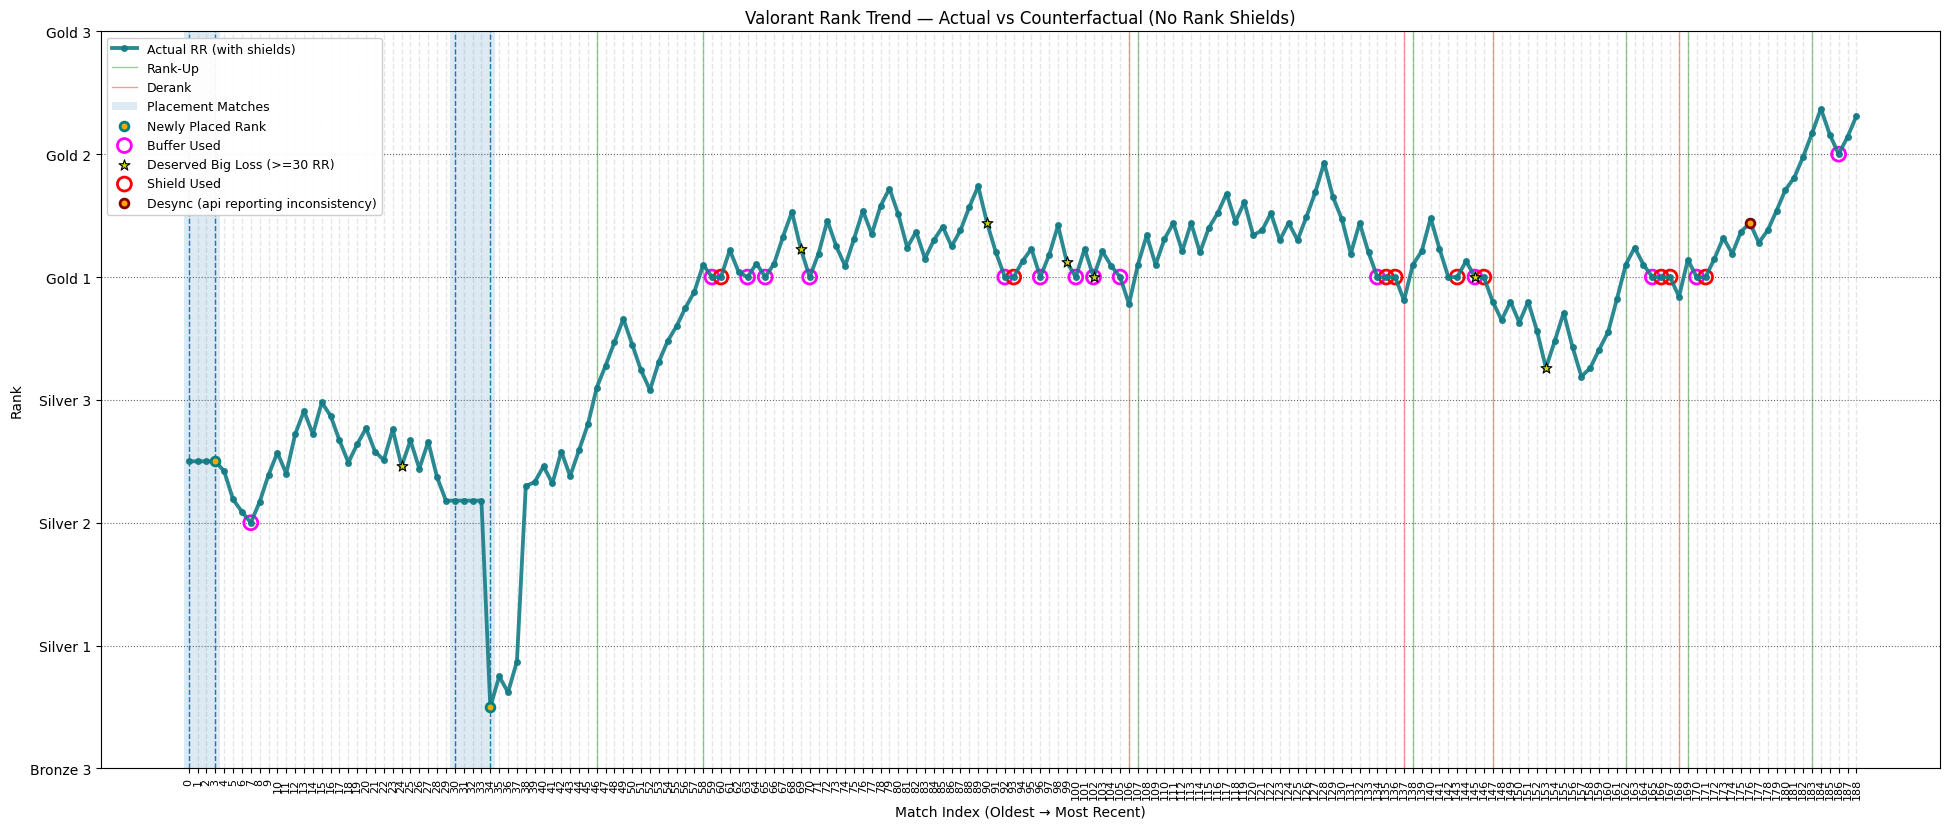

In [34]:
import matplotlib.pyplot as plt

def compute_counterfactual_path(ledger_entries, model_adjustments=False):
    counterfactual_elos = []

    # Initialize with first non-None elo_before
    first_entry = next(entry for entry in ledger_entries if entry['elo_before'] is not None)
    current_elo = first_entry['elo_before']
    
    
    for i, entry in enumerate(ledger_entries):
        match_id = entry['match_data'].match_id
        rr_change = entry['rr_supposed_to_take'] if entry['rr_supposed_to_take'] is not None else 0
        previous_match_id = recent_previous_match[match_id]
        is_newly_placed_rank = entry['is_newly_placed_rank']
        
        
        if model_adjustments and not recent_is_placement[match_id]:
            estimated_mmr = predicted_matches_mmr[match_id] * 100
            hypothetical_rank = current_elo
            current_visual_rank = entry['elo_before']
            rr_change = predict_rr_change(rr_change, current_visual_rank, estimated_mmr, hypothetical_rank)

        # Apply Valorant's loss buffer logic
        if rr_change < 0 and not entry['is_splice']:
            # Current Elo modulo 100
            remainder = current_elo % 100
            # Max loss allowed without crossing multiple of 100
            max_loss = -remainder if remainder != 0 else rr_change
            rr_change = max(rr_change, max_loss)
        
        # Add rr change
        next_elo = current_elo + rr_change

        # Detect tier-up
        if next_elo // 100 > current_elo // 100:
            # promotion happened
            next_elo_in_tier = next_elo % 100
            if next_elo_in_tier < 10:
                next_elo += 10 - next_elo_in_tier
        
        if is_newly_placed_rank or recent_is_placement[match_id]:
            elo_after = entry['elo_after']
            next_elo = elo_after if elo_after is not None else current_elo
        else:
            next_elo = min(next_elo, entry['elo_after'])    # new
            
        counterfactual_elos.append(next_elo)
        current_elo = next_elo

    return counterfactual_elos

def compute_counterfactual_nobuffer_path(ledger_entries, model_adjustments=False):
    counterfactual_elos = []

    # Initialize with first non-None elo_before
    first_entry = next(entry for entry in ledger_entries if entry['elo_before'] is not None)
    current_elo = first_entry['elo_before']
    
    for i, entry in enumerate(ledger_entries):
        match_id = entry['match_data'].match_id
        rr_change = entry['rr_supposed_to_take'] if entry['rr_supposed_to_take'] is not None else 0
        previous_match_id = recent_previous_match[match_id]
        is_newly_placed_rank = entry['is_newly_placed_rank']
        
        if model_adjustments and not recent_is_placement[match_id]:
            estimated_mmr = predicted_matches_mmr[match_id] * 100
            hypothetical_rank = current_elo
            current_visual_rank = entry['elo_before']
            rr_change = predict_rr_change(rr_change, current_visual_rank, estimated_mmr, hypothetical_rank)
            
        # Add rr change
        next_elo = current_elo + rr_change
        if is_newly_placed_rank or recent_is_placement[match_id]:
            elo_after = entry['elo_after']
            next_elo = elo_after if elo_after is not None else current_elo
        else:
            next_elo = min(next_elo, entry['elo_after'])    # new    
        
        counterfactual_elos.append(next_elo)
        current_elo = next_elo

    return counterfactual_elos

# Prepare data
ledger = build_match_ledger(recent_mmr)
excluded_match_id = next(iter(ledger.items()))[0]
ledger_entries = list(ledger.values())[1:]
actual_elos = [entry['elo_after'] for entry in ledger_entries]


WITH_NO_BUFFER = True
WITH_ADJ = True
counterfactual_elos = compute_counterfactual_path(ledger_entries)
counterfactual_nobuffer_elos = compute_counterfactual_nobuffer_path(ledger_entries)

counterfactual_elos_adj = compute_counterfactual_path(ledger_entries, True)
counterfactual_nobuffer_elos_adj = compute_counterfactual_nobuffer_path(ledger_entries, True)

match_indices = list(range(len(ledger_entries)))

counterfactuals = counterfactual_nobuffer_elos if WITH_NO_BUFFER else counterfactual_elos

# Compute nice Y-ticks based on actual ELO range
actual_elos = [elo if elo is not None else counterfactuals[i] for i, elo in enumerate(actual_elos)]
min_elo = min(min(actual_elos), min(counterfactuals))
max_elo = max(max(actual_elos), max(counterfactuals))

plt.figure(figsize=(14*1.4,6*1.4))

# Define a cohesive color palette and style
colors = {
    'actual': "#147C86",      
    'no_shields': "#F18F01",
    'no_shields_adj': '#F18F01',
    'no_buffer': '#6A4C93',   
    'no_buffer_adj': "#6A4C93" 
}

# # Actual Elo
# plt.plot(match_indices, actual_elos, label="Actual RR (with shields)", color='blue', marker=".", markersize=5)

# # Counterfactual Elo
# plt.plot(match_indices, counterfactual_elos, label="No Shields RR", linestyle='--', color='orange', marker=".", markersize=5)
# if WITH_ADJ:
#     plt.plot(match_indices, counterfactual_elos_adj, label="No Shields RR (modeled adjustments)", linestyle=':', color="#DD3304", marker=".", markersize=5)
    
# if WITH_NO_BUFFER:
#     plt.plot(match_indices, counterfactual_nobuffer_elos, label="No Buffer RR", linestyle='--', color="#8a77c9", marker=".", markersize=5)
#     if WITH_ADJ:
#         plt.plot(match_indices, counterfactual_nobuffer_elos_adj, label="No Buffer RR (modeled adjustments)", linestyle=':', color="#848ae1", marker=".", markersize=5)

# Actual Elo - make it stand out as the baseline
plt.plot(match_indices, actual_elos, 
         label="Actual RR (with shields)", 
         color=colors['actual'], 
         linewidth=2.75, 
         marker="o", 
         markersize=4,
         zorder=100,
         alpha=0.9)

# # No Shields - primary comparison
# plt.plot(match_indices, counterfactual_elos, 
#          label="No Shields RR", 
#          linestyle='-', 
#          color=colors['no_shields'], 
#          linewidth=2,
#          marker="s", 
#          markersize=3,
#          alpha=0.8)

# if WITH_ADJ:
#     plt.plot(match_indices, counterfactual_elos_adj, 
#              label="No Shields RR (adjusted)", 
#              linestyle=':', 
#              color=colors['no_shields_adj'], 
#              linewidth=1.5,
#              marker="^", 
#              markersize=3,
#              alpha=0.6)

# if WITH_NO_BUFFER:
#     plt.plot(match_indices, counterfactual_nobuffer_elos, 
#              label="No Buffer RR", 
#              linestyle='-', 
#              color=colors['no_buffer'], 
#              linewidth=2,
#              marker="d", 
#              markersize=3,
#              alpha=0.8)
    
#     if WITH_ADJ:
#         plt.plot(match_indices, counterfactual_nobuffer_elos_adj, 
#                  label="No Buffer RR (adjusted)", 
#                  linestyle=':', 
#                  color=colors['no_buffer_adj'], 
#                  linewidth=1.5,
#                  marker="v", 
#                  markersize=3,
#                  alpha=0.6)
        

# # Compute per-match delta contributions
# previous_delta = 0
# total_delta = 0
# deltas = []
# for i, (cf, actual) in enumerate(zip(counterfactual_elos, actual_elos)):
#     if actual is not None:
#         # Individual match contribution
#         individual_delta = (actual - cf) - previous_delta
#         deltas.append(individual_delta)
#         total_delta += individual_delta
#         previous_delta += individual_delta  # update cumulative

#         if individual_delta != 0 and abs(individual_delta) < 100:
#             # Draw vertical line for this match's contribution
#             color = "magenta"
#             if individual_delta > 0:
#                 ymin = cf
#                 ymax = cf + individual_delta
#             else:
#                 color = "blue"
#                 ymin = cf + individual_delta
#                 ymax = cf

#             plt.vlines(
#                 x=i,
#                 ymin=ymin,
#                 ymax=ymax,
#                 colors=color,
#                 linestyles='solid',
#                 linewidth=2,
#                 zorder=100
#             )          

def add_rank_tier_lines(ax, rank_names, color="black", linestyle=":", linewidth=0.8, alpha=0.6):
    """
    Draw horizontal lines at 100-RR tier boundaries for selected rank names.
    rank_names: list[str], e.g. ["Silver 1", "Gold 2", "Platinum 3"]
    """
    for rank in VALORANT_RANKS:
        for target in rank_names:
            if target in rank:
                y = VALORANT_RANKS.index(rank) * 100
                ax.axhline(y, color=color, linestyle=linestyle,
                        linewidth=linewidth, alpha=alpha, zorder=0, clip_on=True)


# Only show Silver & Gold tier boundaries
ax = plt.gca()
add_rank_tier_lines(ax, rank_names=["Bronze", "Silver", "Gold", "Platinum", "Diamond", "Ascendant"])

# Faint vertical dashed lines without affecting y-axis
for x in match_indices:
    ax.axvline(
        x=x,
        color='gray',
        linestyle='dashed',
        alpha=0.2,
        linewidth=1
    )

# Highlight rank-up events and add to legend
rankup_alpha = 0.4
rank_up_plotted = False
for i, entry in enumerate(ledger_entries):
    null_check = not(entry['elo_after'] is None or entry['elo_before'] is None)
    if entry['tier_after'] != entry['tier_before'] and entry['tier_before'] is not None and null_check and entry['elo_after'] > entry['elo_before']:
        plt.axvline(i, color='green', alpha=rankup_alpha, linestyle='-', linewidth=1, label="Rank-Up" if not rank_up_plotted else "")
        rank_up_plotted = True

# Highlight derank events and add to legend
derank_plotted = False
for i, entry in enumerate(ledger_entries):
    null_check = not(entry['elo_after'] is None or entry['elo_before'] is None)
    if entry['tier_after'] != entry['tier_before'] and entry['tier_before'] is not None and null_check and entry['elo_after'] < entry['elo_before']:
        plt.axvline(i, color='red', alpha=rankup_alpha, linestyle='-', linewidth=1, label="Derank" if not derank_plotted else "")
        derank_plotted = True


# Event definitions: condition, plot type, and plot kwargs
events = {
    'splice': {
        'cond': lambda e: e.get('is_splice'),
        'type': 'axvline',
        'kwargs': dict(color='black', linewidth=2, alpha=0.4, zorder=0, linestyle='--', label="Data Splice (matches missing)")
    },
    'shield': {
        'cond': lambda e: e.get('shield_used'),
        'type': 'scatter',
        'kwargs': dict(s=100, facecolors='none', edgecolors='red', linewidths=2, label="Shield Used")
    },
    'rr_desync': {
        'cond': lambda e: e.get('rr_desync'),
        'type': 'scatter',
        'kwargs': dict(s=40, facecolors='orange', edgecolors='maroon', zorder=100, linewidths=2, label="Desync (api reporting inconsistency)")
    },
    'is_newly_placed_rank': {
        'cond': lambda e: e.get('is_newly_placed_rank'),
        'type': 'scatter',
        'kwargs': dict(s=40, facecolors='orange', edgecolors='teal', zorder=100, linewidths=2, label="Newly Placed Rank")
    },
    'buffer': {
        'cond': lambda e: e.get('buffer_used') and not e.get('shield_used'),
        'type': 'scatter',
        'kwargs': dict(s=100, facecolors='none', edgecolors='magenta', linewidths=2, label="Buffer Used")
    },
    'big_loss': {
        'cond': lambda e: e.get('big_loss'),
        'type': 'scatter',
        'kwargs': dict(marker='*', s=67, color="#CAD40D", edgecolors='black', linewidths=0.8, zorder=100, label=f"Deserved Big Loss (>={BIG_LOSS_THRESHOLD_RR} RR)")
    }
}


placement_ranges = calculate_placement_regions(reverse=True, offset=-1)
first = True
for start, end in placement_ranges:
    ax.axvline(start, linestyle="--", linewidth=1)
    ax.axvline(end, linestyle="--", linewidth=1)
    ax.axvspan(start - 0.5, end + 0.5, alpha=0.15,
                label="Placement Matches" if first else None)
    first = False


# Track which labels have already been plotted
plotted = {k: False for k in events}
# Single loop over entries
for i, e in enumerate(ledger_entries):
    for k, v in events.items():
        if v['cond'](e):
            kwargs = v['kwargs'].copy()
            if plotted[k]:
                kwargs.pop('label', None)
            plotted[k] = True
            if v['type'] == 'axvline':
                plt.axvline(i, **kwargs)
            else:
                plt.scatter(i, e['elo_after'], **kwargs)

# Set y-axis limits tightly around data
plt.ylim(min_elo - 10, max_elo + 10)  # small padding for visibility

# Round ticks to nearest 100 for labels
yticks = list(range((min_elo//100)*100, ((max_elo//100)+2)*100, 100))
ylabels = [map_rank_value(val/100, include_rr=False) if val > 0 else "" for val in yticks]
plt.yticks(yticks, ylabels)

# Map to rank names (skip zero or negative)
ylabels = [map_rank_value(val/100, include_rr=False) if val > 0 else "" for val in yticks]

plt.yticks(yticks, ylabels)

plt.xlabel(f"Match Index (Oldest → Most Recent)")
plt.ylabel("Rank")
plt.title("Valorant Rank Trend — Actual vs Counterfactual (No Rank Shields)")

ticks = np.array(match_indices)
labels = ticks
plt.xticks(ticks, labels, rotation=90, fontsize=8)

# plt.legend(loc="lower left")
plt.legend(loc='best', framealpha=0.95, fontsize=9)
plt.tight_layout()
plt.show()

In [35]:
last_match = recent_matches[0].metadata.match_id
last_last_match = recent_matches[1].metadata.match_id
estimated_mmr = predicted_matches_mmr[last_match] * 100

last_rr = recent_mmr[last_match].last_mmr_change
current_elo = recent_mmr[last_last_match].elo
counter_elo = counterfactual_nobuffer_elos_adj[-2]

print(f"Current MMR: {map_rank_value(estimated_mmr / 100)}")
print(f"Current Rank: {map_rank_value(current_elo/100)}")
print(f"Counterfactual Rank (nobuffer, adj): {map_rank_value(counter_elo/100)}")
counter_rr = predict_rr_change(last_rr, current_elo, estimated_mmr, counter_elo)
print(f"As {map_rank_value(current_elo/100)}, I earned {last_rr}rr last match, but as {map_rank_value(counter_elo/100)} I would've earned {counter_rr}rr.")

Current MMR: Silver 2 41 RR
Current Rank: Gold 2 14 RR
Counterfactual Rank (nobuffer, adj): Silver 3 89 RR
As Gold 2 14 RR, I earned 17rr last match, but as Silver 3 89 RR I would've earned 19rr.


In [36]:
def agent_team_percentage(matches, agent_name: str) -> float:
    total_teams = 0
    agent_teams = 0

    for match in matches:
        # group players by team
        teams = {}
        for player in match.players:
            teams.setdefault(player.team_id, []).append(player)

        # each match has two teams
        total_teams += 2

        # check each team once
        for team_players in teams.values():
            if any(p.character == agent_name for p in team_players):
                agent_teams += 1

    if total_teams == 0:
        return 0.0

    return (agent_teams / total_teams) * 100

agent_team_percentage(recent_matches, "Viper")

# len(recent_matches)

8.157894736842106

In [37]:
from api_valorant_assets import ValAssetApi
from api_henrik import Player, Match

def calculate_agent_stats(matches: List[Match], excluded_puuid: str):
    """Calculate comprehensive stats for each agent across all matches."""
    agent_stats = {}
    
    for match in matches:
        winning_team_id = ([team_id for team_id, data in match.teams.as_dict().items() if data['has_won']]+[None])[0]
        for player in match.players:
            if player.puuid == excluded_puuid:
                continue
                        
            agent = player.character
            
            if agent not in agent_stats:
                agent_stats[agent] = {
                    'picks': 0,
                    'teams': 0,
                    'wins': 0,
                    'kills': 0,
                    'deaths': 0,
                    'assists': 0,
                    'matches_seen': set()
                }
            
            # Track individual player stats
            agent_stats[agent]['picks'] += 1
            agent_stats[agent]['kills'] += player.stats.kills
            agent_stats[agent]['deaths'] += player.stats.deaths
            agent_stats[agent]['assists'] += player.stats.assists
            agent_stats[agent]['matches_seen'].add(match.metadata.match_id)
            
            # Track wins (assuming player has won attribute)
            player_won = player.team_id.lower() == winning_team_id
            if player_won:
                agent_stats[agent]['wins'] += 1
    
    # Now calculate team appearances correctly
    for match in matches:
        # Group players by team
        teams = {}
        for player in match.players:
            teams.setdefault(player.team_id, []).append(player)
        
        # Check each team in this match
        for team_players in teams.values():
            # Find which agents were on this team
            agents_on_team = set(p.character for p in team_players if p.puuid != excluded_puuid)
            
            # Increment team count for each agent that appeared
            for agent in agents_on_team:
                if agent in agent_stats:
                    agent_stats[agent]['teams'] += 1
                    
    for agent in agent_stats:
        agent_stats[agent]['matches_seen'] = len(agent_stats[agent]['matches_seen'])
    
    return agent_stats

# calculate_agent_stats(recent_matches, my_account.puuid)

In [38]:
from typing import List, Dict
from api_valorant_assets import ValAssetApi
from api_henrik import Player, Match

def calculate_role_percentages(matches: List[Match], excluded_puuid: str) -> Dict[str, float]:
    """
    Calculate the percentage of team compositions that included each role,
    ignoring the excluded player's impact.
    
    Returns a dict of role_name -> percentage (0-100).
    """
    agent_api = ValAssetApi()
    role_counts = {}  # role -> count of teams that had it
    total_teams = 0

    for match in matches:
        # Group players by team
        teams = {}
        excluded_team = None
        for player in match.players:
            if player.puuid == excluded_puuid:
                excluded_team = player.team_id
            teams.setdefault(player.team_id, []).append(player)

        for team_id, team_players in teams.items():
            if team_id == excluded_team:
                continue
            
            total_teams += 1
            # Track roles present on the team excluding the excluded player
            roles_in_team = set()
            for player in team_players:
                # if player.puuid == excluded_puuid:
                #     continue  # skip excluded player
                agent = player.character
                role = agent_api.agents[agent].role.displayName
                roles_in_team.add(role)

            for role in roles_in_team:
                role_counts[role] = role_counts.get(role, 0) + 1

    # Convert counts to percentages
    role_percentages = {role: f"{(count / total_teams):.1%}" for role, count in role_counts.items()}

    return role_percentages

calculate_role_percentages(recent_matches, my_account.puuid)

{'Sentinel': '91.1%',
 'Controller': '96.3%',
 'Duelist': '99.5%',
 'Initiator': '83.2%'}

In [39]:
from api_valorant_assets import ValAssetApi


def generate_html_report(matches, excluded_puuid: str, output_file='index.html'):
    """Generate an interactive HTML page with agent statistics."""
    
    assets = ValAssetApi()
    stats = calculate_agent_stats(matches, excluded_puuid)
    representation_stats = calculate_role_percentages(recent_matches, my_account.puuid)
    
    # Calculate total teams across all matches
    total_teams = len(matches) * 2
    
    # Prepare agent data with all calculated stats
    agent_data_list = []
    for agent_name, agent_data in stats.items():
        agent_info = assets.agents.get(agent_name)
        
        if agent_info:
            icon = agent_info.displayIconSmall or agent_info.displayIcon
            role = agent_info.role.displayName if agent_info.role else "Unknown"
        else:
            icon = ""
            role = "Unknown"
        
        picks = agent_data['picks']
        teams = agent_data['teams']
        team_percentage = (teams / total_teams * 100) if total_teams > 0 else 0
        matches_seen = agent_data['matches_seen']
        matches_seen_percentage = (matches_seen / len(matches) * 100) if len(matches) > 0 else 0
        win_rate = (agent_data['wins'] / picks * 100) if picks > 0 else 0
        
        kills = agent_data['kills']
        deaths = agent_data['deaths']
        assists = agent_data['assists']
        kda = ((kills + assists) / deaths) if deaths > 0 else kills + assists
        
        agent_data_list.append({
            'name': agent_name,
            'icon': icon,
            'role': role,
            'teams': teams,
            'team_percentage': team_percentage,
            'picks': picks,
            'matches_seen': matches_seen,
            'matches_seen_percentage': matches_seen_percentage,
            'win_rate': win_rate,
            # 'kills': kills,
            # 'deaths': deaths,
            # 'assists': assists,
            'kda': kda
        })
    
    # Convert to JavaScript array
    import json
    agents_json = json.dumps(agent_data_list)
    representation_json = json.dumps(representation_stats)
    
    html_content = f'''<!DOCTYPE html>
<html lang="en">
<head>
    <meta charset="UTF-8">
    <meta name="viewport" content="width=device-width, initial-scale=1.0">
    <title>Valorant Agent Statistics</title>
    <style>
        * {{
            margin: 0;
            padding: 0;
            box-sizing: border-box;
        }}
        
        body {{
            font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
            background: linear-gradient(135deg, #0f1923 0%, #1a2733 100%);
            color: #ece8e1;
            min-height: 100vh;
            padding: 20px;
        }}
        
        .container {{
            max-width: 1600px;
            margin: 0 auto;
        }}
        
        header {{
            text-align: center;
            margin-bottom: 30px;
            padding: 30px 0;
            border-bottom: 2px solid #ff4655;
        }}
        
        h1 {{
            font-size: 3em;
            color: #ff4655;
            text-transform: uppercase;
            letter-spacing: 3px;
            margin-bottom: 10px;
            text-shadow: 0 0 20px rgba(255, 70, 85, 0.5);
        }}
        
        .summary {{
            text-align: center;
            font-size: 1.2em;
            color: #b0aca7;
            margin-top: 10px;
        }}
        
        .controls {{
            background: rgba(255, 255, 255, 0.05);
            border-radius: 10px;
            padding: 20px;
            margin-bottom: 30px;
            display: flex;
            gap: 20px;
            flex-wrap: wrap;
            align-items: center;
            backdrop-filter: blur(10px);
            border: 1px solid rgba(255, 255, 255, 0.1);
        }}
        
        .control-group {{
            display: flex;
            align-items: center;
            gap: 10px;
        }}
        
        .control-group label {{
            color: #b0aca7;
            font-weight: 500;
        }}

        input[type="number"] {{
            background: #f9f9f9;       
            color: #333;               
            border: 1px solid rgba(0, 0, 0, 0.2);
            padding: 10px 15px;        
            border-radius: 5px;        
            font-size: 1em;            
            cursor: text;              
            transition: all 0.3s ease;
        }}

        /* Optional: hover/focus effect to match buttons/selects */
        input[type="number"]:hover,
        input[type="number"]:focus {{
            border-color: rgba(0, 0, 0, 0.4);
            outline: none;
        }}
        
        select, button {{
            background: rgba(255, 255, 255, 0.1);
            border: 1px solid rgba(255, 255, 255, 0.2);
            color: #fff;
            padding: 10px 15px;
            border-radius: 5px;
            font-size: 1em;
            cursor: pointer;
            transition: all 0.3s ease;
        }}
        
        select:hover, button:hover {{
            background: rgba(255, 70, 85, 0.3);
            border-color: #ff4655;
        }}
        
        select:focus, button:focus {{
            outline: none;
            border-color: #ff4655;
        }}
        
        select option {{
            background-color: white;   /* white background */
            color: #333;               /* dark text */
        }}        
        
        .checkbox-group {{
            display: flex;
            align-items: center;
            gap: 8px;
        }}
        
        input[type="checkbox"] {{
            width: 18px;
            height: 18px;
            cursor: pointer;
        }}
        
        .stats-table {{
            width: 100%;
            background: rgba(255, 255, 255, 0.05);
            border-radius: 10px;
            # overflow: auto;
            backdrop-filter: blur(10px);
            border: 1px solid rgba(255, 255, 255, 0.1);
        }}
        
        .stats-table thead {{
            position: sticky;
            top: 0;
            z-index: 10;
        }}
        
        table {{
            width: 100%;
            border-collapse: collapse;
        }}
        
        thead {{
            background: #4a2d37;
        }}
        
        th {{
            padding: 15px;
            text-align: left;
            font-weight: 600;
            color: #fff;
            text-transform: uppercase;
            font-size: 0.9em;
            letter-spacing: 1px;
        }}
        
        th.sortable {{
            cursor: pointer;
            user-select: none;
        }}
        
        th.sortable:hover {{
            background: rgba(255, 70, 85, 0.3);
        }}
        
        th.sorted {{
            color: #ff4655;
        }}
        
        tbody tr {{
            border-bottom: 1px solid rgba(255, 255, 255, 0.05);
            transition: all 0.2s ease;
        }}
        
        tbody tr:hover {{
            background: rgba(255, 255, 255, 0.05);
        }}
        
        td {{
            padding: 15px;
            color: #ece8e1;
        }}
        
        .agent-cell {{
            display: flex;
            align-items: center;
            gap: 12px;
        }}
        
        .agent-icon {{
            width: 40px;
            height: 40px;
            border-radius: 50%;
            border: 2px solid #ff4655;
            object-fit: cover;
        }}
        
        .agent-info {{
            display: flex;
            flex-direction: column;
        }}
        
        .agent-name {{
            font-weight: bold;
            font-size: 1.1em;
            color: #fff;
        }}
        
        .agent-role {{
            font-size: 0.85em;
            color: #ff4655;
            text-transform: uppercase;
        }}
        
        .stat-number {{
            font-weight: 600;
            font-size: 1.05em;
        }}
        
        .percentage {{
            color: #00d4aa;
        }}
        
        .kda {{
            color: #ffd966;
        }}
        
        .role-header {{
            background: rgba(255, 70, 85, 0.15);
            padding: 12px 15px;
            font-weight: bold;
            font-size: 1.1em;
            color: #ff4655;
            text-transform: uppercase;
            letter-spacing: 1px;
        }}
        
        .role-section {{
            border-top: 2px solid #ff4655;
        }}
    </style>
</head>
<body>
    <div class="container">
        <header>
            <h1>Agent Statistics</h1>
            <div class="summary">
                Total Matches: {len(matches)} | Total Teams: {total_teams} | Unique Agents: {len(stats)}
            </div>
        </header>
        
        <div class="controls">
            <div class="control-group">
                <label for="sortBy">Sort by:</label>
                <select id="sortBy">
                    <option value="team_percentage">Team Pick Rate</option>
                    <option value="matches_seen_percentage">Matches Seen %</option>
                    <option value="win_rate">Win Rate</option>
                    <option value="kda">KDA Ratio</option>
                    <option value="name">Agent Name</option>
                </select>
            </div>
            
            <div class="control-group">
                <label for="sortOrder">Order:</label>
                <select id="sortOrder">
                    <option value="desc">Descending</option>
                    <option value="asc">Ascending</option>
                </select>
            </div>
            
            <div class="control-group">
                <label for="minMatches">Minimum Matches:</label>
                <input type="number" id="minMatches" min="0" value="10" step="1">
            </div>
            
            <div class="checkbox-group">
                <input type="checkbox" id="groupByRole">
                <label for="groupByRole">Group by Role</label>
            </div>
        </div>
        
        <div class="stats-table">
            <table>
                <thead>
                    <tr>
                        <th>Agent</th>
                        <th class="sortable" data-sort="teams">Team Appearances</th>
                        <th class="sortable" data-sort="team_percentage">Team Pick Rate</th>
                        <th class="sortable" data-sort="matches_seen_percentage">Matches Seen %</th>
                        <th class="sortable" data-sort="win_rate">Win Rate</th>
                        <th class="sortable" data-sort="kda">KDA Ratio</th>
                    </tr>
                </thead>
                <tbody id="agentTableBody">
                </tbody>
            </table>
        </div>
    </div>
    
    <script>
        const agentsData = {agents_json};
        const reprData = {representation_json};
        let currentSort = 'team_percentage';
        let currentOrder = 'desc';
        let groupByRole = false;
        
        function renderTable() {{
            const tbody = document.getElementById('agentTableBody');
            tbody.innerHTML = '';
            
            const minMatchesInput = document.getElementById('minMatches');
            const minMatches = Number(minMatchesInput.value);

            let sortedAgents = [...agentsData];
            sortedAgents = sortedAgents.filter(agent => agent.matches_seen >= minMatches);
            
            // Sort data
            sortedAgents.sort((a, b) => {{
                let valA = a[currentSort];
                let valB = b[currentSort];
                
                if (typeof valA === 'string') {{
                    valA = valA.toLowerCase();
                    valB = valB.toLowerCase();
                }}
                
                if (currentOrder === 'asc') {{
                    return valA > valB ? 1 : -1;
                }} else {{
                    return valA < valB ? 1 : -1;
                }}
            }});
            
            if (groupByRole) {{
                // Group by role
                const grouped = {{}};
                sortedAgents.forEach(agent => {{
                    if (!grouped[agent.role]) {{
                        grouped[agent.role] = [];
                    }}
                    grouped[agent.role].push(agent);
                }});
                
                // Render grouped
                Object.keys(grouped).sort().forEach(role => {{
                    const headerRow = document.createElement('tr');
                    headerRow.className = 'role-section';
                    
                    headerRow.innerHTML = `<td colspan="7" class="role-header">${{role}} (play rate ${{reprData[role]}})</td>`;
                    tbody.appendChild(headerRow);
                    
                    grouped[role].forEach(agent => {{
                        tbody.appendChild(createAgentRow(agent));
                    }});
                }});
            }} else {{
                // Render flat list
                sortedAgents.forEach(agent => {{
                    tbody.appendChild(createAgentRow(agent));
                }});
            }}
            
            // Update sorted header indicators
            document.querySelectorAll('th.sortable').forEach(th => {{
                th.classList.remove('sorted');
            }});
            const sortedHeader = document.querySelector(`th[data-sort="${{currentSort}}"]`);
            if (sortedHeader) {{
                sortedHeader.classList.add('sorted');
            }}

            document.querySelectorAll('.winrate-filter').forEach(el => {{
                const value = parseFloat(el.textContent.replace('%', ''));
                el.style.color = '#d40055';
                el.style.textShadow = 'none'; // remove glow if not >55

                if (value >= 55) {{
                    el.style.color = '#00d4aa';
                    el.style.textShadow = '0 0 8px #00d4aa'; // glow effect
                }}
                else if (value >= 50.5) {{
                    el.style.color = '#00d4aa';
                    el.style.textShadow = 'none'; // remove glow if not >55
                }}
                else if (value >= 45) {{
                    el.style.color = '#fff';
                    el.style.textShadow = 'none'; // remove glow if not >55
                }}
            }});            
        }}
        
        function createAgentRow(agent) {{
            const row = document.createElement('tr');
            row.innerHTML = `
                <td>
                    <div class="agent-cell">
                        <img src="${{agent.icon}}" alt="${{agent.name}}" class="agent-icon">
                        <div class="agent-info">
                            <div class="agent-name">${{agent.name}}</div>
                            <div class="agent-role">${{agent.role}}</div>
                        </div>
                    </div>
                </td>
                <td class="stat-number">${{agent.teams}}</td>
                <td class="stat-number percentage">${{agent.team_percentage.toFixed(1)}}%</td>
                <td class="stat-number"> <span class="percentage">${{agent.matches_seen_percentage.toFixed(1)}}%</span> (<span class="stat-number">${{agent.matches_seen}}</span>)</td>
                
                <td class="stat-number winrate-filter percentage">${{agent.win_rate.toFixed(1)}}%</td>
                <td class="stat-number kda">${{agent.kda.toFixed(2)}}</td>
            `;
            return row;
        }}
        
        // Event listeners
        document.getElementById('sortBy').addEventListener('change', (e) => {{
            currentSort = e.target.value;
            renderTable();
        }});
        
        document.getElementById('sortOrder').addEventListener('change', (e) => {{
            currentOrder = e.target.value;
            renderTable();
        }});
        
        document.getElementById('groupByRole').addEventListener('change', (e) => {{
            groupByRole = e.target.checked;
            renderTable();
        }});
        
        document.querySelectorAll('th.sortable').forEach(th => {{
            th.addEventListener('click', () => {{
                const sortKey = th.dataset.sort;
                if (currentSort === sortKey) {{
                    currentOrder = currentOrder === 'desc' ? 'asc' : 'desc';
                }} else {{
                    currentSort = sortKey;
                    currentOrder = 'desc';
                }}
                document.getElementById('sortBy').value = currentSort;
                document.getElementById('sortOrder').value = currentOrder;
                renderTable();
            }});
        }});
        
        document.getElementById('minMatches').addEventListener('keydown', (event) => {{
        if (event.key === 'Enter') {{
            renderTable();
        }}
        }});
        
        
        // Initial render
        renderTable();
    </script>
</body>
</html>
'''
    
    # Write to file
    with open(output_file, 'w', encoding='utf-8') as f:
        f.write(html_content)
    
    print(f"Report generated successfully: {output_file}")
    return output_file

# Usage example:
generate_html_report(recent_matches, my_account.puuid)

Report generated successfully: index.html


'index.html'